# Генератор детерминированного шума Талера

Краткий ноутбук для построения орбиты отображения Талера и последовательности возмущений \(z_k\).


In [1]:
# Импорт библиотек для численных расчётов, таблиц и графиков.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


In [2]:
# Основные параметры генерации шума Талера.
# EPSILON задаёт область включения шума: z_k != 0 только при x_k < EPSILON.
# X0 — начальная точка орбиты, N — число сохраняемых точек, BURN_IN — число пропускаемых начальных итераций.

EPSILON = 0.10
X0 = 0.323456789
N = 200
BURN_IN = 0

PARAMS = [
    {
        "name": "s03_beta018",
        "s": 0.30,
        "beta": 0.18,
        "epsilon": EPSILON,
        "x0": X0,
    },
    {
        "name": "s03_beta028",
        "s": 0.30,
        "beta": 0.28,
        "epsilon": EPSILON,
        "x0": X0,
    },
    {
        "name": "s03_beta038",
        "s": 0.30,
        "beta": 0.38,
        "epsilon": EPSILON,
        "x0": X0,
    },

    {
        "name": "s05_beta018",
        "s": 0.50,
        "beta": 0.18,
        "epsilon": EPSILON,
        "x0": X0,
    },
    {
        "name": "s05_beta028",
        "s": 0.50,
        "beta": 0.28,
        "epsilon": EPSILON,
        "x0": X0,
    },
    {
        "name": "s05_beta038",
        "s": 0.50,
        "beta": 0.38,
        "epsilon": EPSILON,
        "x0": X0,
    },

    {
        "name": "s08_beta018",
        "s": 0.70,
        "beta": 0.18,
        "epsilon": EPSILON,
        "x0": X0,
    },
    {
        "name": "s07_beta028",
        "s": 0.70,
        "beta": 0.28,
        "epsilon": EPSILON,
        "x0": X0,
    },
    {
        "name": "s07_beta038",
        "s": 0.70,
        "beta": 0.38,
        "epsilon": EPSILON,
        "x0": X0,
    },
]

pd.DataFrame(PARAMS)


,name,s,beta,epsilon,x0
0,s03_beta018,0.3,0.18,0.1,0.323457
1,s03_beta028,0.3,0.28,0.1,0.323457
2,s03_beta038,0.3,0.38,0.1,0.323457
3,s05_beta018,0.5,0.18,0.1,0.323457
4,s05_beta028,0.5,0.28,0.1,0.323457
5,s05_beta038,0.5,0.38,0.1,0.323457
6,s08_beta018,0.7,0.18,0.1,0.323457
7,s07_beta028,0.7,0.28,0.1,0.323457
8,s07_beta038,0.7,0.38,0.1,0.323457


In [3]:
# Функции отображения Талера и наблюдаемой phi.
# thaler_map строит следующий элемент орбиты x_{k+1}.
# observable_phi переводит точку орбиты x_k в значение шума z_k.

def thaler_map(x: float, s: float) -> float:
    return (x + x ** (1.0 + s)) % 1.0


def observable_phi(x: float, beta: float, epsilon: float) -> float:
    if x >= epsilon:
        return 0.0
    x_safe = max(float(x), 1e-15)
    return float(np.sign(np.sin(2 * np.pi * x_safe)) * (x_safe ** (-beta)))


In [4]:
# Генерация орбиты x_k и соответствующего шума z_k для всех заданных режимов.
# В таблице noise_df сохраняются значения x_k, z_k, |z_k| и индикатор выброса.

def generate_thaler_noise(
    s: float,
    beta: float,
    epsilon: float,
    x0: float,
    n: int,
    burn_in: int
) -> pd.DataFrame:
    x = float(x0)

    for _ in range(burn_in):
        x = thaler_map(x, s)

    rows = []

    for k in range(n):
        z = observable_phi(x, beta, epsilon)

        rows.append({
            "k": k,
            "x": x,
            "z": z,
            "abs_z": abs(z),
            "is_burst": int(x < epsilon),
        })

        x = thaler_map(x, s)

    return pd.DataFrame(rows)


all_dfs = []

for p in PARAMS:
    df = generate_thaler_noise(
        s=p["s"],
        beta=p["beta"],
        epsilon=p["epsilon"],
        x0=p["x0"],
        n=N,
        burn_in=BURN_IN,
    )

    df.insert(0, "regime", p["name"])
    df["s"] = p["s"]
    df["beta"] = p["beta"]
    df["epsilon"] = p["epsilon"]
    df["x0"] = p["x0"]

    all_dfs.append(df)

noise_df = pd.concat(all_dfs, ignore_index=True)

print("Общая таблица noise_df собрана.")
print("Размер noise_df:", noise_df.shape)
print("Число режимов:", noise_df["regime"].nunique())
print("Режимы:", list(noise_df["regime"].unique()))
print(f"N = {N}: столько точек сохранено для каждого режима.")
print(f"BURN_IN = {BURN_IN}: столько первых шагов орбиты пропущено перед записью.")

print("\nПервые 12 строк общей таблицы:")
display(noise_df.head(12).reset_index(drop=True))

cols_to_show = ["regime", "k", "x", "z", "abs_z", "is_burst", "s", "beta", "epsilon"]

for regime in noise_df["regime"].unique():
    print("\n" + "=" * 100)
    print(f"Первые 20 строк режима: {regime}")
    print("=" * 100)

    df_regime = noise_df.loc[
        noise_df["regime"] == regime,
        cols_to_show
    ].head(50)

    display(df_regime.reset_index(drop=True))


Общая таблица noise_df собрана.
Размер noise_df: (1800, 10)
Число режимов: 9
Режимы: ['s03_beta018', 's03_beta028', 's03_beta038', 's05_beta018', 's05_beta028', 's05_beta038', 's08_beta018', 's07_beta028', 's07_beta038']
N = 200: столько точек сохранено для каждого режима.
BURN_IN = 0: столько первых шагов орбиты пропущено перед записью.

Первые 12 строк общей таблицы:


,regime,k,x,z,abs_z,is_burst,s,beta,epsilon,x0
0,s03_beta018,0,0.323457,0.000000,0.000000,0,0.3,0.18,0.1,0.323457
1,s03_beta018,1,0.554005,0.000000,0.000000,0,0.3,0.18,0.1,0.323457
2,s03_beta018,2,0.018058,2.059688,2.059688,1,0.3,0.18,0.1,0.323457
3,s03_beta018,3,0.023473,1.964702,1.964702,1,0.3,0.18,0.1,0.323457
4,s03_beta018,4,0.031090,1.867795,1.867795,1,0.3,0.18,0.1,0.323457
5,s03_beta018,5,0.042064,1.768867,1.768867,1,0.3,0.18,0.1,0.323457
6,s03_beta018,6,0.058323,1.667817,1.667817,1,0.3,0.18,0.1,0.323457
7,s03_beta018,7,0.083189,1.564546,1.564546,1,0.3,0.18,0.1,0.323457
8,s03_beta018,8,0.122642,0.000000,0.000000,0,0.3,0.18,0.1,0.323457
9,s03_beta018,9,0.187990,0.000000,0.000000,0,0.3,0.18,0.1,0.323457



Первые 20 строк режима: s03_beta018


,regime,k,x,z,abs_z,is_burst,s,beta,epsilon
0,s03_beta018,0,0.323457,0.000000,0.000000,0,0.3,0.18,0.1
1,s03_beta018,1,0.554005,0.000000,0.000000,0,0.3,0.18,0.1
2,s03_beta018,2,0.018058,2.059688,2.059688,1,0.3,0.18,0.1
3,s03_beta018,3,0.023473,1.964702,1.964702,1,0.3,0.18,0.1
4,s03_beta018,4,0.031090,1.867795,1.867795,1,0.3,0.18,0.1
5,s03_beta018,5,0.042064,1.768867,1.768867,1,0.3,0.18,0.1
6,s03_beta018,6,0.058323,1.667817,1.667817,1,0.3,0.18,0.1
7,s03_beta018,7,0.083189,1.564546,1.564546,1,0.3,0.18,0.1
8,s03_beta018,8,0.122642,0.000000,0.000000,0,0.3,0.18,0.1
9,s03_beta018,9,0.187990,0.000000,0.000000,0,0.3,0.18,0.1



Первые 20 строк режима: s03_beta028


...

,regime,k,x,z,abs_z,is_burst,s,beta,epsilon
0,s08_beta018,0,0.323457,0.000000,0.000000,0,0.7,0.18,0.1
1,s08_beta018,1,0.470244,0.000000,0.000000,0,0.7,0.18,0.1
2,s08_beta018,2,0.747543,0.000000,0.000000,0,0.7,0.18,0.1
3,s08_beta018,3,0.357336,0.000000,0.000000,0,0.7,0.18,0.1
4,s08_beta018,4,0.531208,0.000000,0.000000,0,0.7,0.18,0.1
5,s08_beta018,5,0.872361,0.000000,0.000000,0,0.7,0.18,0.1
6,s08_beta018,6,0.665198,0.000000,0.000000,0,0.7,0.18,0.1
7,s08_beta018,7,0.165251,0.000000,0.000000,0,0.7,0.18,0.1
8,s08_beta018,8,0.212115,0.000000,0.000000,0,0.7,0.18,0.1
9,s08_beta018,9,0.283758,0.000000,0.000000,0,0.7,0.18,0.1



Первые 20 строк режима: s07_beta028


,regime,k,x,z,abs_z,is_burst,s,beta,epsilon
0,s07_beta028,0,0.323457,0.000000,0.000000,0,0.7,0.28,0.1
1,s07_beta028,1,0.470244,0.000000,0.000000,0,0.7,0.28,0.1
2,s07_beta028,2,0.747543,0.000000,0.000000,0,0.7,0.28,0.1
3,s07_beta028,3,0.357336,0.000000,0.000000,0,0.7,0.28,0.1
4,s07_beta028,4,0.531208,0.000000,0.000000,0,0.7,0.28,0.1
5,s07_beta028,5,0.872361,0.000000,0.000000,0,0.7,0.28,0.1
6,s07_beta028,6,0.665198,0.000000,0.000000,0,0.7,0.28,0.1
7,s07_beta028,7,0.165251,0.000000,0.000000,0,0.7,0.28,0.1
8,s07_beta028,8,0.212115,0.000000,0.000000,0,0.7,0.28,0.1
9,s07_beta028,9,0.283758,0.000000,0.000000,0,0.7,0.28,0.1



Первые 20 строк режима: s07_beta038


,regime,k,x,z,abs_z,is_burst,s,beta,epsilon
0,s07_beta038,0,0.323457,0.000000,0.000000,0,0.7,0.38,0.1
1,s07_beta038,1,0.470244,0.000000,0.000000,0,0.7,0.38,0.1
2,s07_beta038,2,0.747543,0.000000,0.000000,0,0.7,0.38,0.1
3,s07_beta038,3,0.357336,0.000000,0.000000,0,0.7,0.38,0.1
4,s07_beta038,4,0.531208,0.000000,0.000000,0,0.7,0.38,0.1
5,s07_beta038,5,0.872361,0.000000,0.000000,0,0.7,0.38,0.1
6,s07_beta038,6,0.665198,0.000000,0.000000,0,0.7,0.38,0.1
7,s07_beta038,7,0.165251,0.000000,0.000000,0,0.7,0.38,0.1
8,s07_beta038,8,0.212115,0.000000,0.000000,0,0.7,0.38,0.1
9,s07_beta038,9,0.283758,0.000000,0.000000,0,0.7,0.38,0.1


In [5]:
# Сводная диагностика шума по каждому режиму.
# nonzero_share — доля ненулевых значений z_k, max_abs_z — максимальный модуль шума.

summary_rows = []
for regime, g in noise_df.groupby("regime"):
    abs_z = g["abs_z"].values
    z = g["z"].values
    summary_rows.append({
        "regime": regime,
        "s": g["s"].iloc[0],
        "beta": g["beta"].iloc[0],
        "epsilon": g["epsilon"].iloc[0],
        "n": len(g),
        "z_min": float(np.min(z)),
        "z_max": float(np.max(z)),
        "z_mean": float(np.mean(z)),
        "z_std": float(np.std(z)),
        "nonzero_share": float(np.mean(abs_z > 0)),
        "max_abs_z": float(np.max(abs_z)),
        "q90_abs_z": float(np.quantile(abs_z, 0.90)),
        "q95_abs_z": float(np.quantile(abs_z, 0.95)),
        "q99_abs_z": float(np.quantile(abs_z, 0.99)),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,regime,s,beta,epsilon,n,z_min,z_max,z_mean,z_std,nonzero_share,max_abs_z,q90_abs_z,q95_abs_z,q99_abs_z
0,s03_beta018,0.3,0.18,0.1,200,0.0,2.501448,0.422158,0.805786,0.22,2.501448,1.904668,2.150673,2.414630
1,s03_beta028,0.3,0.28,0.1,200,0.0,4.163024,0.611962,1.190390,0.22,4.163024,2.724518,3.291086,3.940446
2,s03_beta038,0.3,0.38,0.1,200,0.0,6.928295,0.892929,1.782853,0.22,6.928295,3.897366,5.036224,6.430433
3,s05_beta018,0.5,0.18,0.1,200,0.0,2.030643,0.397164,0.729949,0.23,2.030643,1.717463,1.868990,1.969552
4,s05_beta028,0.5,0.28,0.1,200,0.0,3.009824,0.539588,0.998049,0.23,3.009824,2.319428,2.645454,2.870154
5,s05_beta038,0.5,0.38,0.1,200,0.0,4.461168,0.734655,1.371281,0.23,4.461168,3.132381,3.744501,4.182566
6,s07_beta028,0.7,0.28,0.1,200,0.0,3.428940,0.518326,1.027406,0.21,3.428940,2.333273,2.677827,3.342910
7,s07_beta038,0.7,0.38,0.1,200,0.0,5.324618,0.721632,1.457690,0.21,5.324618,3.157781,3.807553,5.144133
8,s08_beta018,0.7,0.18,0.1,200,0.0,2.208164,0.373944,0.731671,0.21,2.208164,1.724048,1.883494,2.172387


In [6]:
# Просмотр первых значений орбиты и шума по каждому режиму.
# Столбец k показывает номер шага внутри соответствующего режима.

cols_to_show = ["k", "x", "z", "abs_z", "is_burst"]

for regime in noise_df["regime"].unique():
    print("\n" + "=" * 90)
    print(f"Режим: {regime}")
    print("=" * 90)

    df_regime = noise_df.loc[noise_df["regime"] == regime, cols_to_show].head(20)

    display(df_regime.reset_index(drop=True))



Режим: s03_beta018


,k,x,z,abs_z,is_burst
0,0,0.323457,0.000000,0.000000,0
1,1,0.554005,0.000000,0.000000,0
2,2,0.018058,2.059688,2.059688,1
3,3,0.023473,1.964702,1.964702,1
4,4,0.031090,1.867795,1.867795,1
5,5,0.042064,1.768867,1.768867,1
6,6,0.058323,1.667817,1.667817,1
7,7,0.083189,1.564546,1.564546,1
8,8,0.122642,0.000000,0.000000,0
9,9,0.187990,0.000000,0.000000,0



Режим: s03_beta028


,k,x,z,abs_z,is_burst
0,0,0.323457,0.000000,0.000000,0
1,1,0.554005,0.000000,0.000000,0
2,2,0.018058,3.077057,3.077057,1
3,3,0.023473,2.859166,2.859166,1
4,4,0.031090,2.642821,2.642821,1
5,5,0.042064,2.428307,2.428307,1
6,6,0.058323,2.215971,2.215971,1
7,7,0.083189,2.006236,2.006236,1
8,8,0.122642,0.000000,0.000000,0
9,9,0.187990,0.000000,0.000000,0



Режим: s03_beta038


...

,k,x,z,abs_z,is_burst
0,0,0.323457,0.000000,0.000000,0
1,1,0.470244,0.000000,0.000000,0
2,2,0.747543,0.000000,0.000000,0
3,3,0.357336,0.000000,0.000000,0
4,4,0.531208,0.000000,0.000000,0
5,5,0.872361,0.000000,0.000000,0
6,6,0.665198,0.000000,0.000000,0
7,7,0.165251,0.000000,0.000000,0
8,8,0.212115,0.000000,0.000000,0
9,9,0.283758,0.000000,0.000000,0



Режим: s07_beta028


,k,x,z,abs_z,is_burst
0,0,0.323457,0.000000,0.000000,0
1,1,0.470244,0.000000,0.000000,0
2,2,0.747543,0.000000,0.000000,0
3,3,0.357336,0.000000,0.000000,0
4,4,0.531208,0.000000,0.000000,0
5,5,0.872361,0.000000,0.000000,0
6,6,0.665198,0.000000,0.000000,0
7,7,0.165251,0.000000,0.000000,0
8,8,0.212115,0.000000,0.000000,0
9,9,0.283758,0.000000,0.000000,0



Режим: s07_beta038


,k,x,z,abs_z,is_burst
0,0,0.323457,0.000000,0.000000,0
1,1,0.470244,0.000000,0.000000,0
2,2,0.747543,0.000000,0.000000,0
3,3,0.357336,0.000000,0.000000,0
4,4,0.531208,0.000000,0.000000,0
5,5,0.872361,0.000000,0.000000,0
6,6,0.665198,0.000000,0.000000,0
7,7,0.165251,0.000000,0.000000,0
8,8,0.212115,0.000000,0.000000,0
9,9,0.283758,0.000000,0.000000,0


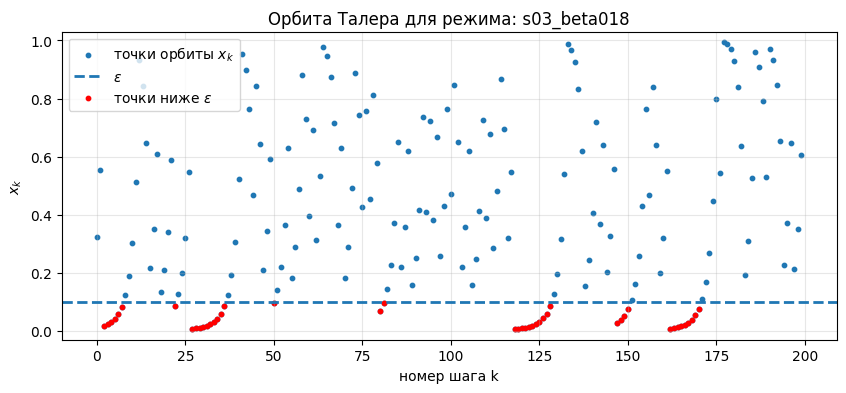

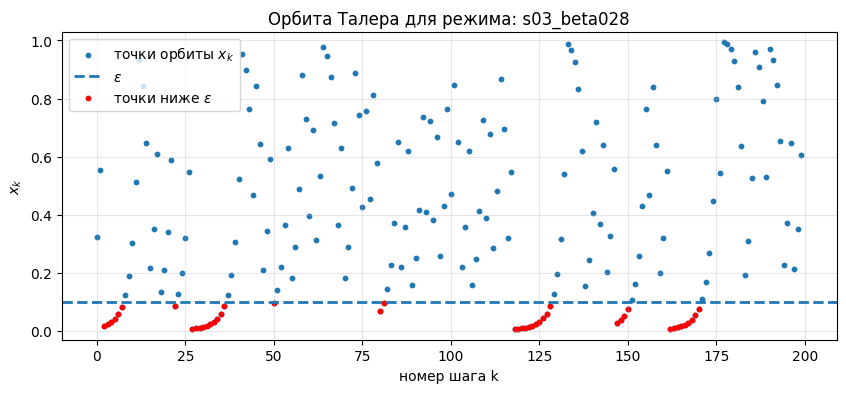

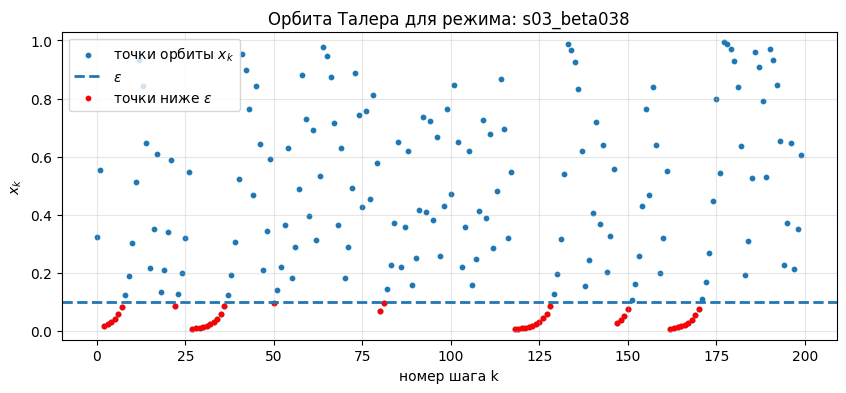

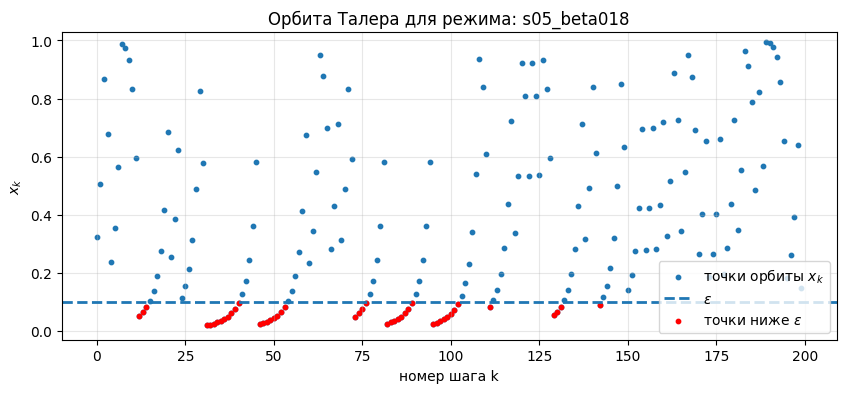

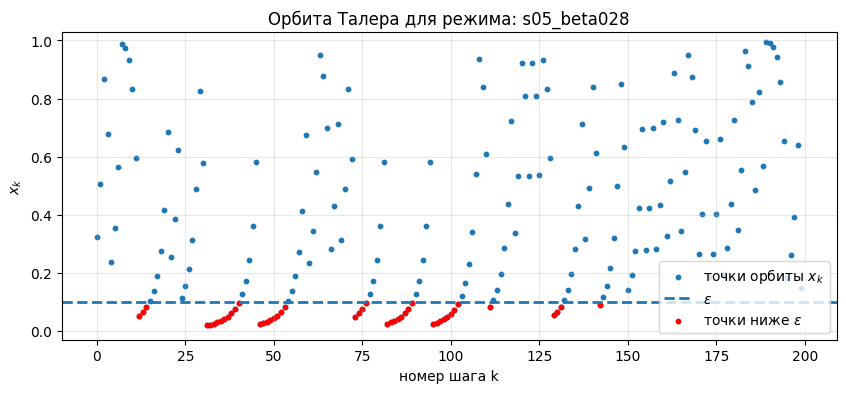

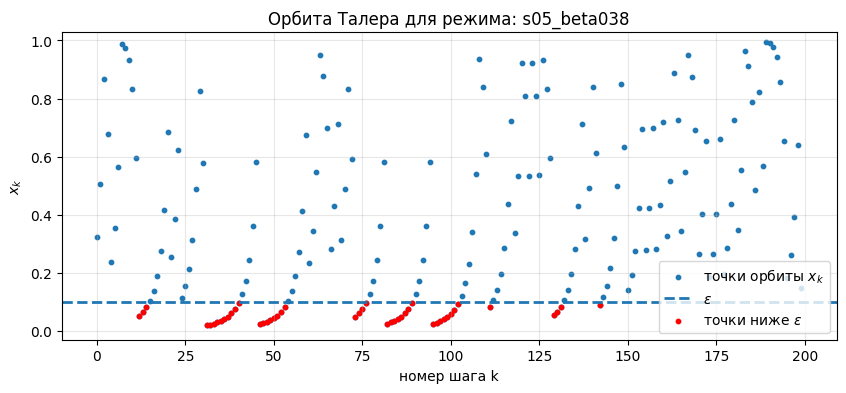

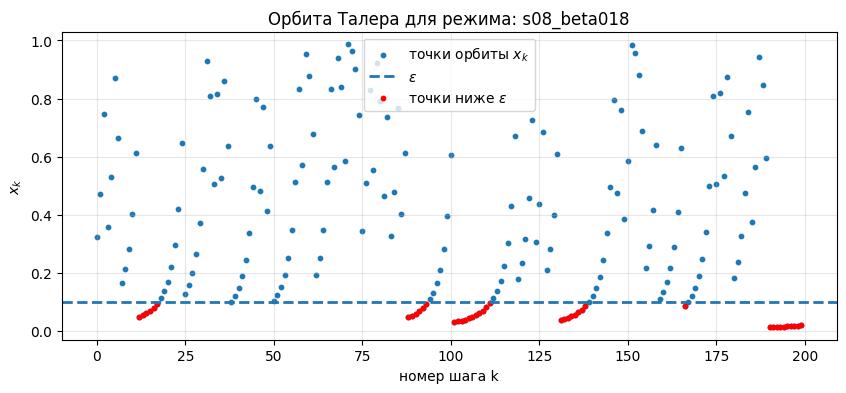

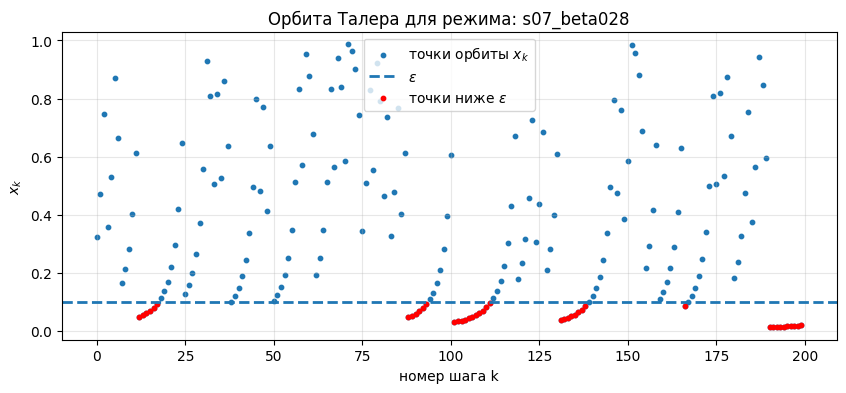

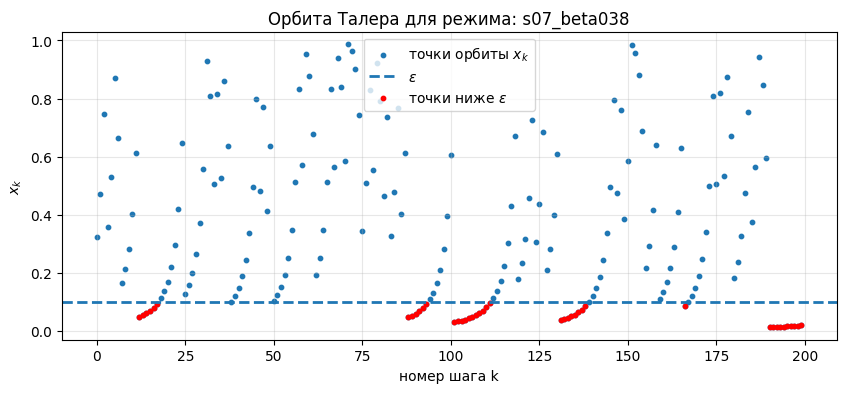

In [7]:
# Графики орбит x_k с порогом epsilon.
# Красные точки соответствуют области x_k < epsilon, где включается шум.

import matplotlib.pyplot as plt

cols_needed = ["regime", "k", "x", "epsilon", "is_burst"]

for regime in noise_df["regime"].unique():
    df_regime = noise_df.loc[
        noise_df["regime"] == regime,
        cols_needed
    ].reset_index(drop=True)

    eps = df_regime["epsilon"].iloc[0]

    plt.figure(figsize=(10, 4))

    plt.scatter(
        df_regime["k"],
        df_regime["x"],
        s=10,
        label="точки орбиты $x_k$"
    )

    plt.axhline(
        y=eps,
        linestyle="--",
        linewidth=2,
        label=r"$\varepsilon$"
    )

    burst_points = df_regime[df_regime["is_burst"] == 1]

    if len(burst_points) > 0:
        plt.scatter(
            burst_points["k"],
            burst_points["x"],
            s=10,
            color="red",
            label=r"точки ниже $\varepsilon$"
        )

    plt.title(f"Орбита Талера для режима: {regime}")
    plt.xlabel("номер шага k")
    plt.ylabel(r"$x_k$")
    plt.ylim(-0.03, 1.03)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


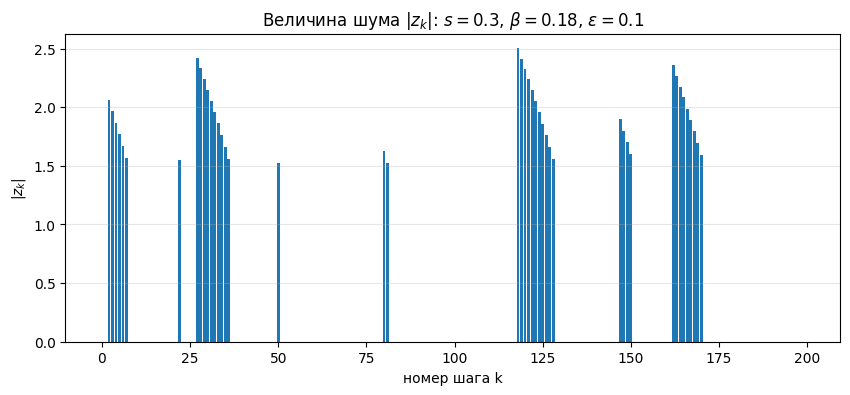

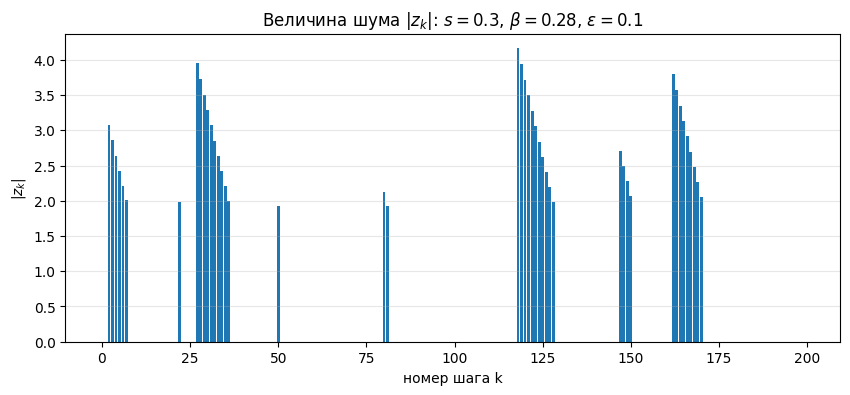

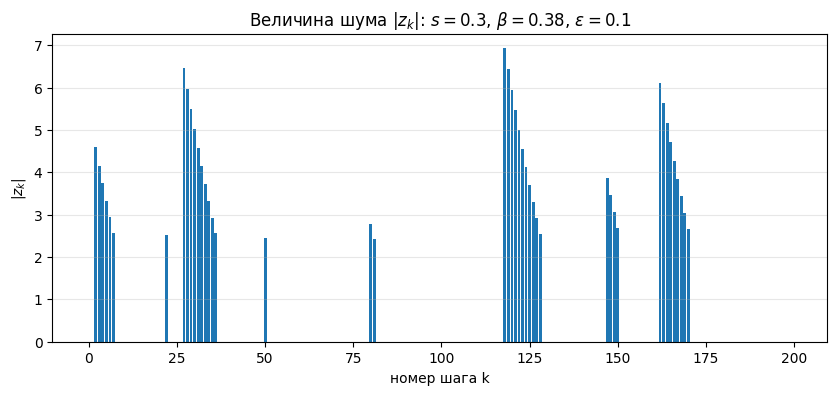

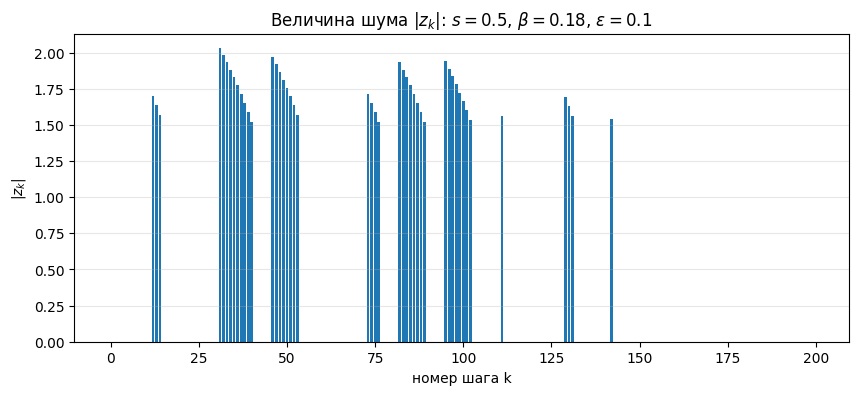

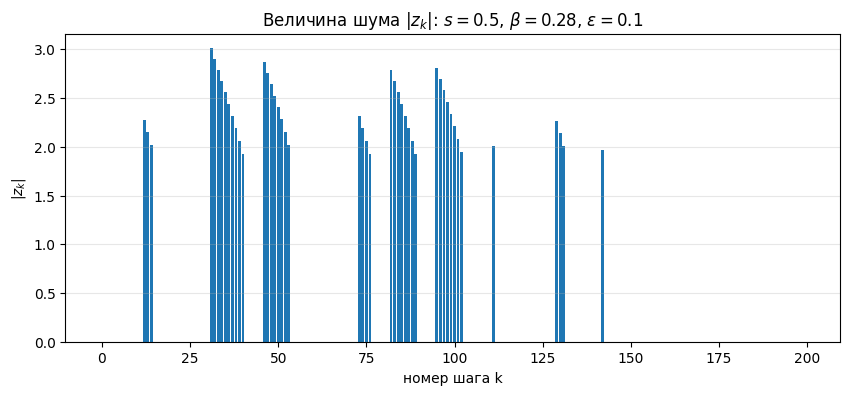

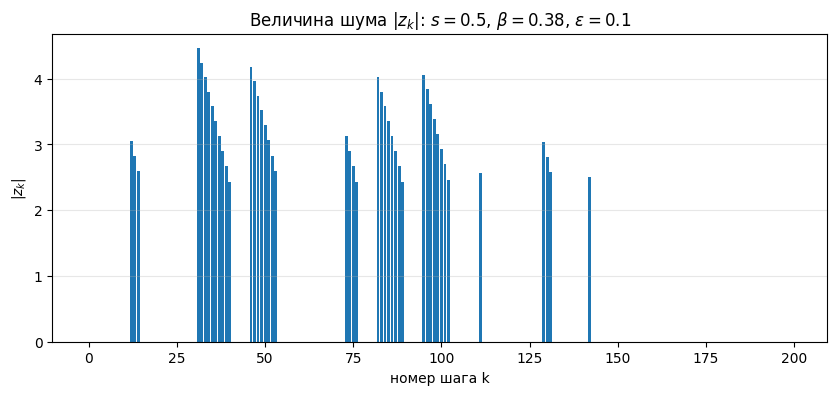

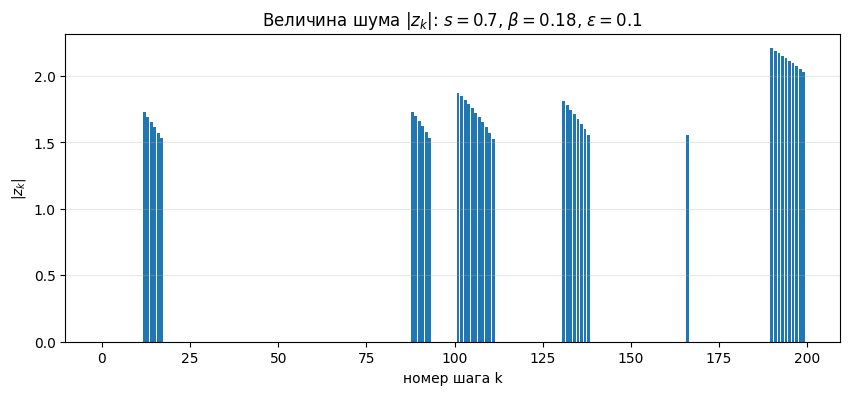

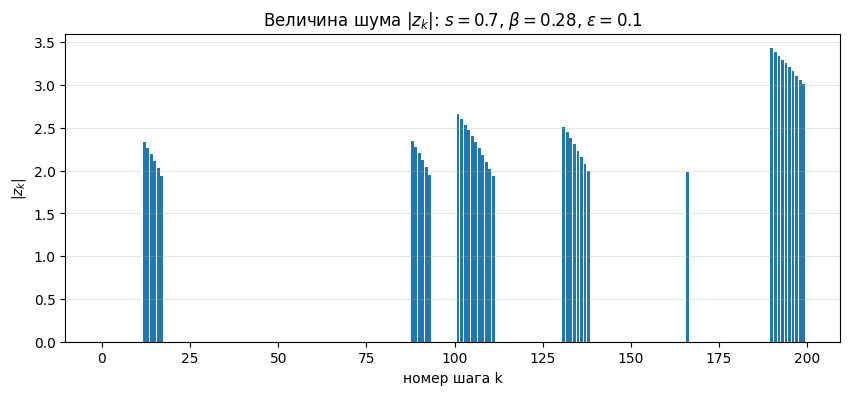

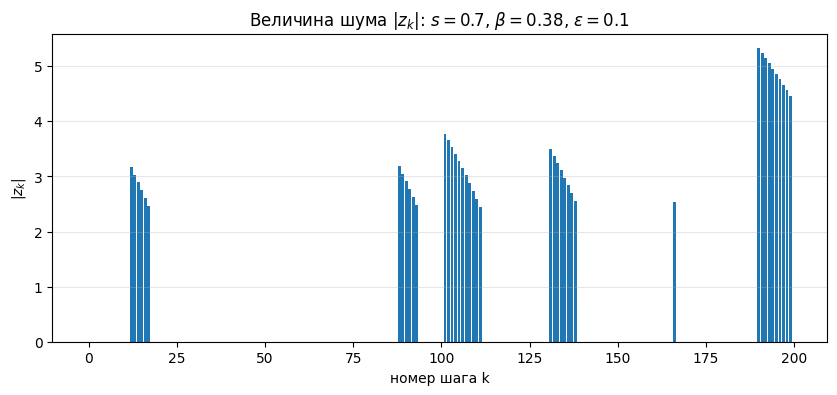

In [8]:
# Столбчатые графики |z_k| для каждого режима.
# Ненулевые столбцы показывают моменты включения шума.

import matplotlib.pyplot as plt

cols_needed = ["regime", "k", "z", "abs_z", "s", "beta", "epsilon", "is_burst"]

for regime in noise_df["regime"].unique():
    df_regime = noise_df.loc[
        noise_df["regime"] == regime,
        cols_needed
    ].reset_index(drop=True)

    s_value = df_regime["s"].iloc[0]
    beta_value = df_regime["beta"].iloc[0]
    eps_value = df_regime["epsilon"].iloc[0]

    plt.figure(figsize=(10, 4))

    plt.bar(
        df_regime["k"],
        df_regime["abs_z"],
        width=0.8
    )

    plt.title(
        rf"Величина шума $|z_k|$: "
        rf"$s={s_value}$, $\beta={beta_value}$, $\varepsilon={eps_value}$"
    )

    plt.xlabel("номер шага k")
    plt.ylabel(r"$|z_k|$")
    plt.grid(True, axis="y", alpha=0.3)

    plt.show()


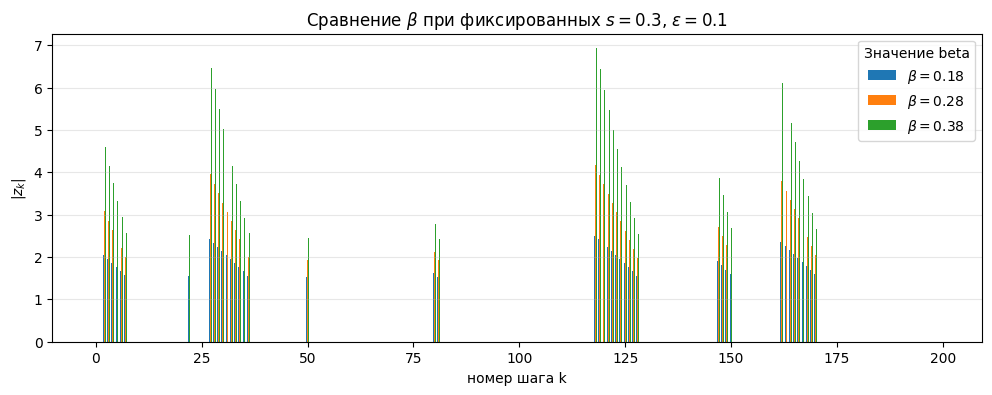

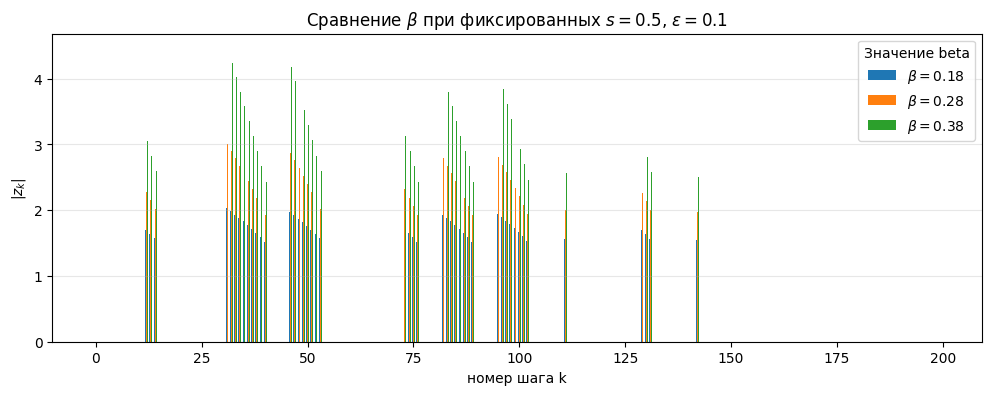

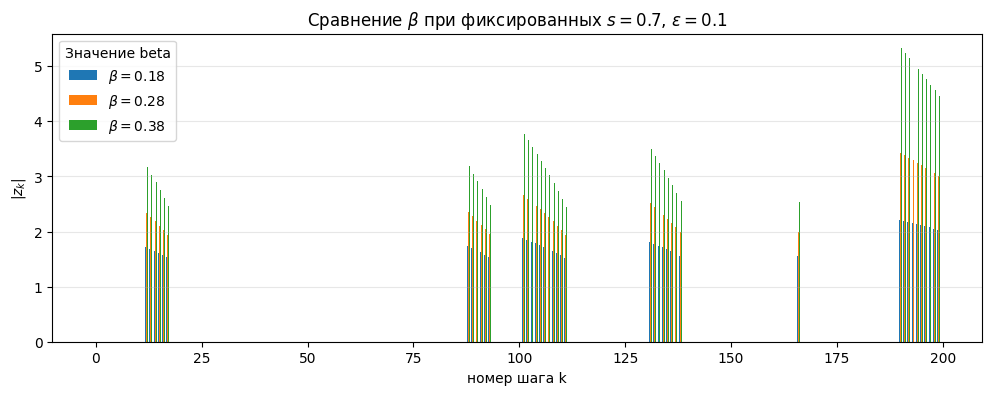

In [9]:
# Сравнение влияния beta при фиксированных s и epsilon.
# При фиксированном s орбита одна и та же; beta меняет только амплитуду выбросов.

import numpy as np
import matplotlib.pyplot as plt

EPS_FIXED = EPSILON

df_beta_compare = noise_df[noise_df["epsilon"] == EPS_FIXED].copy()

s_values = sorted(df_beta_compare["s"].unique())
beta_values = sorted(df_beta_compare["beta"].unique())

bar_width = 0.22

for s_value in s_values:
    df_s = df_beta_compare[df_beta_compare["s"] == s_value].copy()

    plt.figure(figsize=(12, 4))

    for i, beta_value in enumerate(beta_values):
        df_beta = df_s[df_s["beta"] == beta_value].sort_values("k").reset_index(drop=True)

        shift = (i - (len(beta_values) - 1) / 2) * bar_width

        plt.bar(
            df_beta["k"] + shift,
            df_beta["abs_z"],
            width=bar_width,
            label=rf"$\beta={beta_value}$"
        )

    plt.title(
        rf"Сравнение $\beta$ при фиксированных "
        rf"$s={s_value}$, $\varepsilon={EPS_FIXED}$"
    )
    plt.xlabel("номер шага k")
    plt.ylabel(r"$|z_k|$")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend(title="Значение beta")
    plt.show()


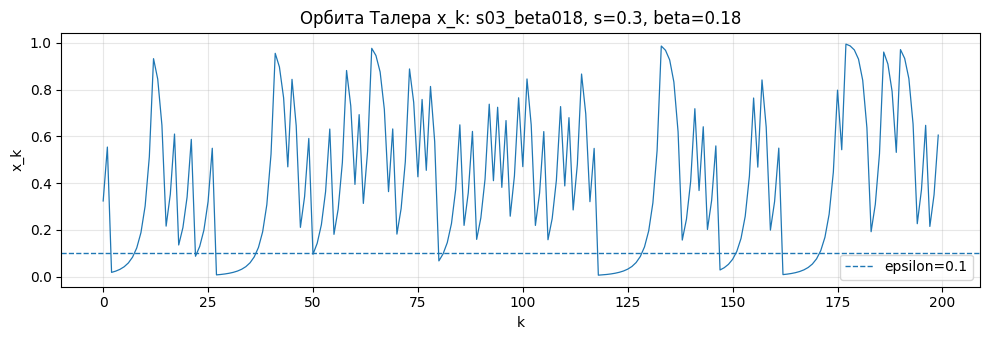

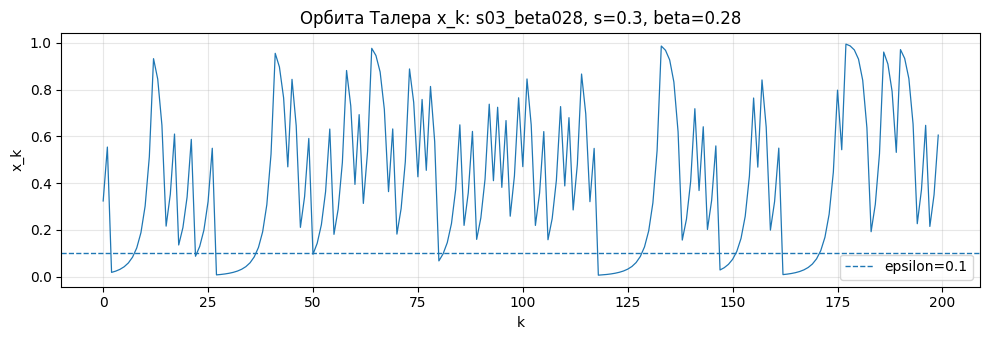

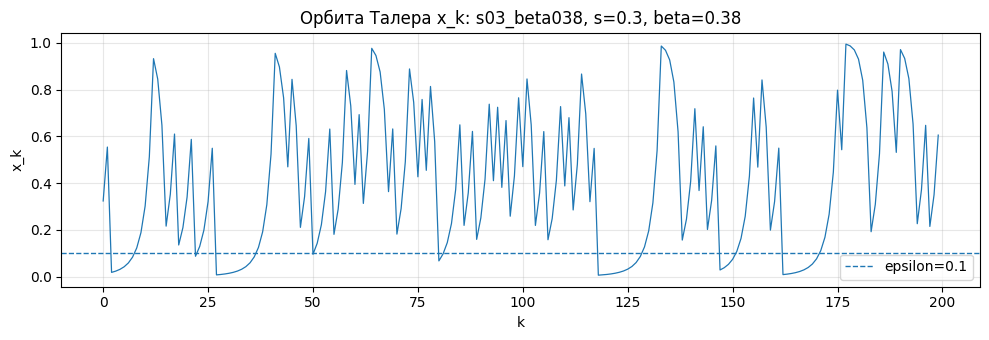

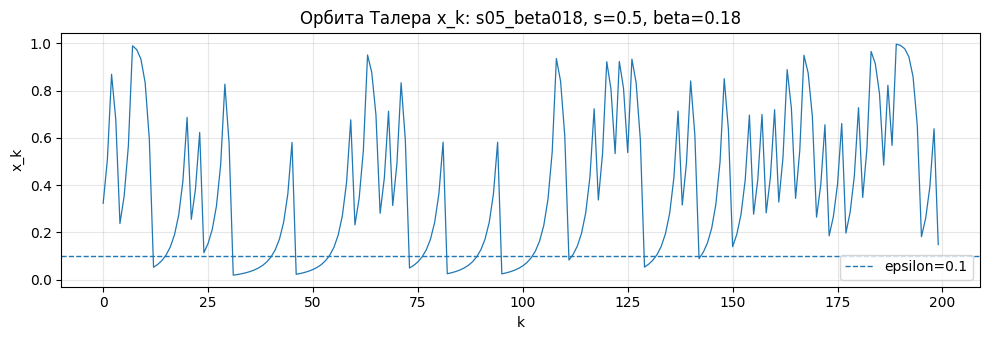

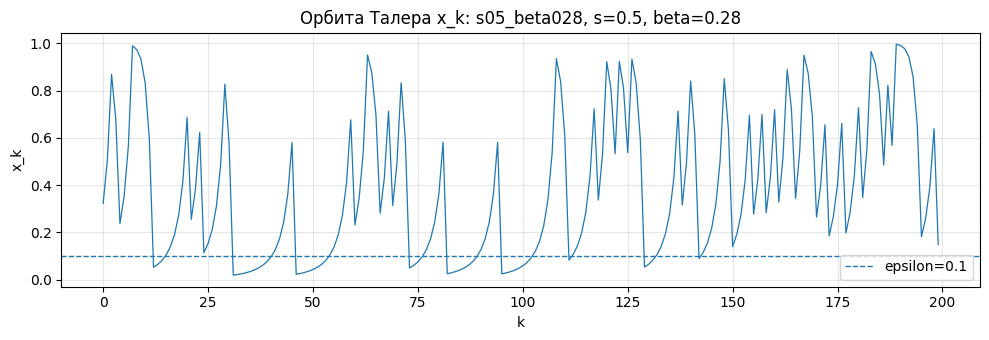

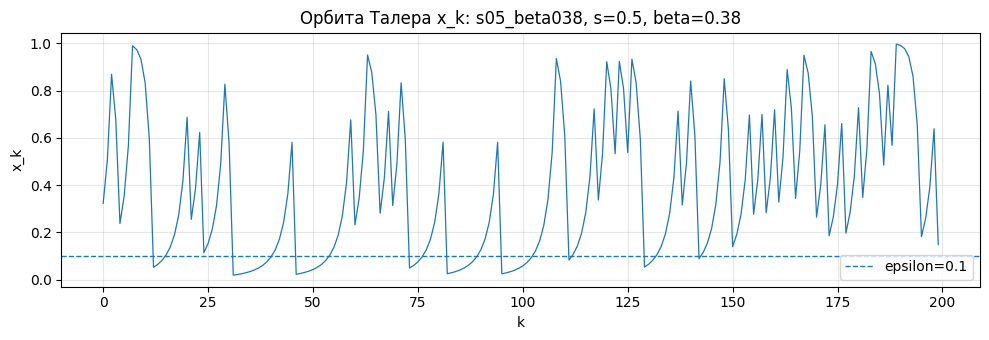

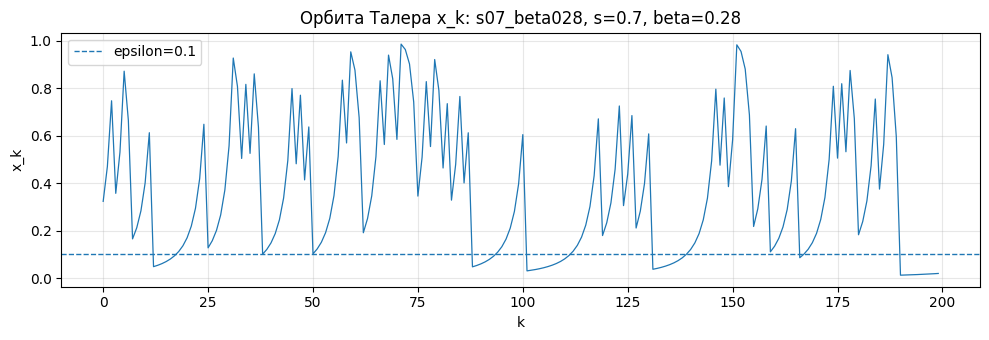

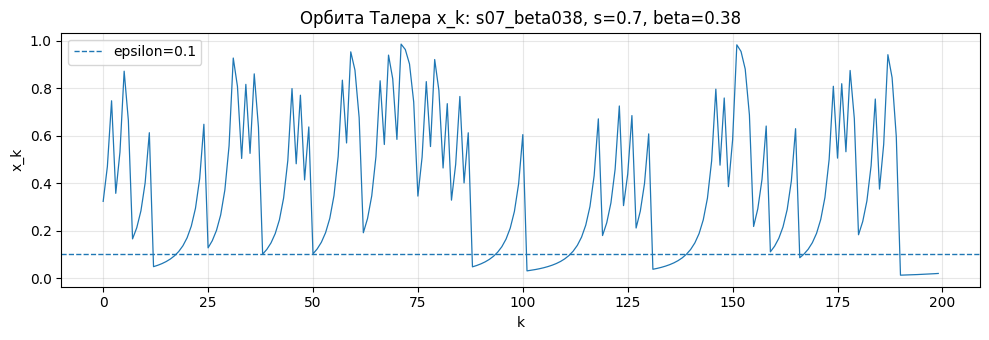

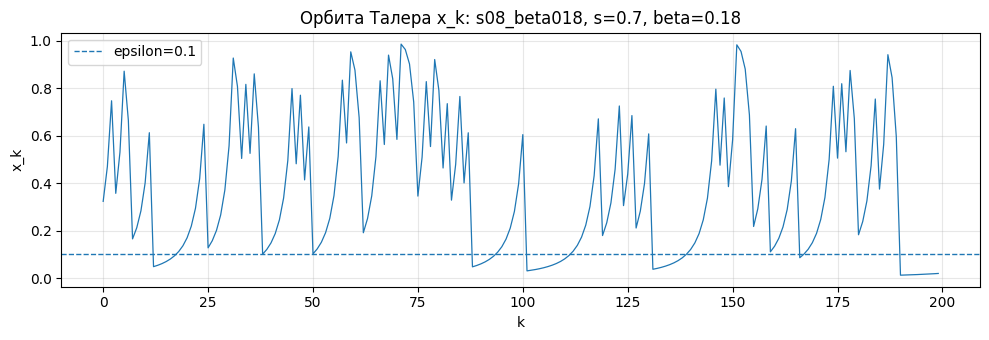

In [10]:
# Графики орбиты x_k для первых PLOT_N итераций после burn-in.

PLOT_N = 500

for regime, g in noise_df.groupby("regime"):
    p = g.iloc[0]
    plt.figure(figsize=(10, 3.5))
    plt.plot(g["k"].iloc[:PLOT_N], g["x"].iloc[:PLOT_N], linewidth=0.9)
    plt.axhline(p["epsilon"], linestyle="--", linewidth=1.0, label=f"epsilon={p['epsilon']}")
    plt.xlabel("k")
    plt.ylabel("x_k")
    plt.title(f"Орбита Талера x_k: {regime}, s={p['s']}, beta={p['beta']}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [11]:
# Эксперимент по влиянию параметра s при фиксированных beta и epsilon.
# При изменении s меняется сама орбита и временная структура выбросов.

import numpy as np
import pandas as pd

BETA_FIXED = 0.28
EPS_FIXED = 0.1

S_SWEEP_VALUES = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

N_S_SWEEP = 3000
BURN_IN_S_SWEEP = 0

s_sweep_dfs = []

for s_value in S_SWEEP_VALUES:
    df = generate_thaler_noise(
        s=s_value,
        beta=BETA_FIXED,
        epsilon=EPS_FIXED,
        x0=X0,
        n=N_S_SWEEP,
        burn_in=BURN_IN_S_SWEEP,
    )

    df.insert(0, "regime", f"s{s_value:.2f}_beta{BETA_FIXED:.2f}")
    df["s"] = s_value
    df["beta"] = BETA_FIXED
    df["epsilon"] = EPS_FIXED
    df["x0"] = X0

    s_sweep_dfs.append(df)

s_sweep_df = pd.concat(s_sweep_dfs, ignore_index=True)

print("Таблица s_sweep_df собрана.")
print("Размер:", s_sweep_df.shape)
print(f"Фиксировано: beta = {BETA_FIXED}, epsilon = {EPS_FIXED}")
print(f"Использовано значений s: {S_SWEEP_VALUES}")
print(f"N = {N_S_SWEEP}, BURN_IN = {BURN_IN_S_SWEEP}")

display(s_sweep_df.head(10))


Таблица s_sweep_df собрана.
Размер: (18000, 10)
Фиксировано: beta = 0.28, epsilon = 0.1
Использовано значений s: [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
N = 3000, BURN_IN = 0


,regime,k,x,z,abs_z,is_burst,s,beta,epsilon,x0
0,s0.20_beta0.28,0,0.323457,0.0,0.0,0,0.2,0.28,0.1,0.323457
1,s0.20_beta0.28,1,0.581552,0.0,0.0,0,0.2,0.28,0.1,0.323457
2,s0.20_beta0.28,2,0.103354,0.0,0.0,0,0.2,0.28,0.1,0.323457
3,s0.20_beta0.28,3,0.168998,0.0,0.0,0,0.2,0.28,0.1,0.323457
4,s0.20_beta0.28,4,0.287427,0.0,0.0,0,0.2,0.28,0.1,0.323457
5,s0.20_beta0.28,5,0.511419,0.0,0.0,0,0.2,0.28,0.1,0.323457
6,s0.20_beta0.28,6,0.958650,0.0,0.0,0,0.2,0.28,0.1,0.323457
7,s0.20_beta0.28,7,0.909237,0.0,0.0,0,0.2,0.28,0.1,0.323457
8,s0.20_beta0.28,8,0.801334,0.0,0.0,0,0.2,0.28,0.1,0.323457
9,s0.20_beta0.28,9,0.567948,0.0,0.0,0,0.2,0.28,0.1,0.323457


In [12]:
# Сводная таблица по влиянию s.
# n_bursts — число ненулевых значений, n_burst_runs — число серий выбросов.
# max_burst_run и mean_burst_run описывают длины подряд идущих серий.

def burst_run_lengths(is_burst_array):
    """Длины подряд идущих серий is_burst = 1."""
    runs = []
    current = 0

    for value in is_burst_array:
        if value == 1:
            current += 1
        else:
            if current > 0:
                runs.append(current)
                current = 0

    if current > 0:
        runs.append(current)

    return runs


rows = []

for s_value, group in s_sweep_df.groupby("s"):
    group = group.sort_values("k").reset_index(drop=True)
    runs = burst_run_lengths(group["is_burst"].values)

    rows.append({
        "s": s_value,
        "beta": BETA_FIXED,
        "epsilon": EPS_FIXED,
        "n": len(group),
        "n_bursts": int(group["is_burst"].sum()),
        "nonzero_share": group["is_burst"].mean(),
        "n_burst_runs": len(runs),
        "max_burst_run": max(runs) if len(runs) > 0 else 0,
        "mean_burst_run": np.mean(runs) if len(runs) > 0 else 0,
        "min_x": group["x"].min(),
        "max_abs_z": group["abs_z"].max(),
        "mean_abs_z": group["abs_z"].mean(),
        "q90_abs_z": group["abs_z"].quantile(0.90),
        "q95_abs_z": group["abs_z"].quantile(0.95),
        "q99_abs_z": group["abs_z"].quantile(0.99),
        "alpha_noise_theory": (1 - s_value) / BETA_FIXED,
    })

s_effect_summary = pd.DataFrame(rows).sort_values("s").reset_index(drop=True)

display(s_effect_summary)


,s,beta,epsilon,n,n_bursts,nonzero_share,n_burst_runs,max_burst_run,mean_burst_run,min_x,max_abs_z,mean_abs_z,q90_abs_z,q95_abs_z,q99_abs_z,alpha_noise_theory
0,0.2,0.28,0.1,3000,419,0.139667,135,20,3.103704,0.000384,9.046946,0.410370,2.129920,2.793808,5.137398,2.857143
1,0.3,0.28,0.1,3000,539,0.179667,128,29,4.210938,0.000514,8.336884,0.541486,2.384027,3.184867,6.019279,2.500000
2,0.4,0.28,0.1,3000,599,0.199667,121,43,4.950413,0.000691,7.673691,0.567019,2.465074,3.208461,4.933509,2.142857
3,0.5,0.28,0.1,3000,746,0.248667,122,64,6.114754,0.000907,7.109847,0.699935,2.631993,3.355043,5.218586,1.785714
4,0.6,0.28,0.1,3000,723,0.241000,91,61,7.945055,0.002294,5.483219,0.667993,2.675607,3.295127,4.686650,1.428571
5,0.7,0.28,0.1,3000,1531,0.510333,64,649,23.921875,0.000159,11.571127,2.850493,9.044885,10.422620,11.355181,1.071429


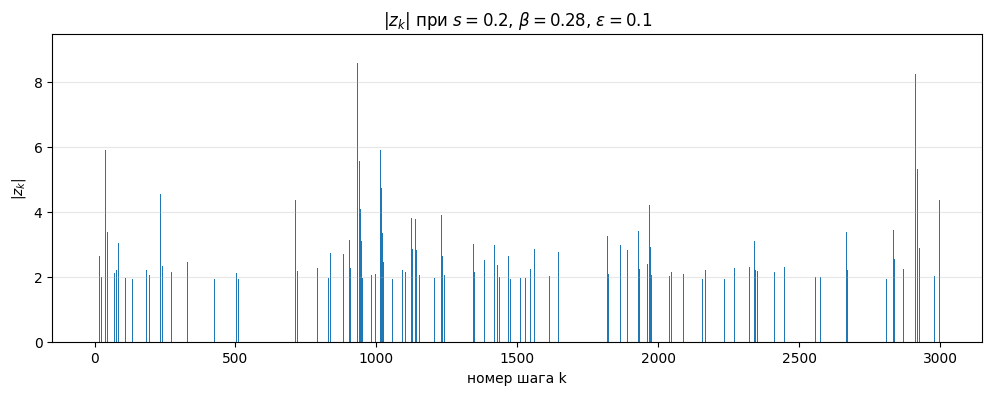

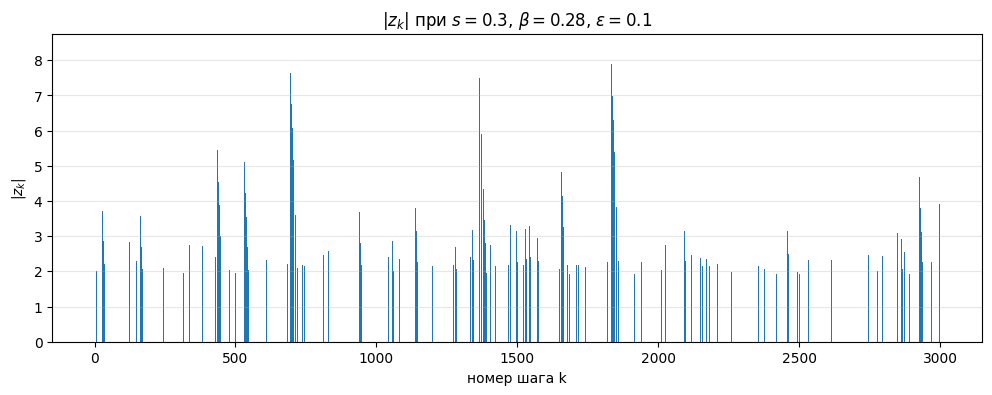

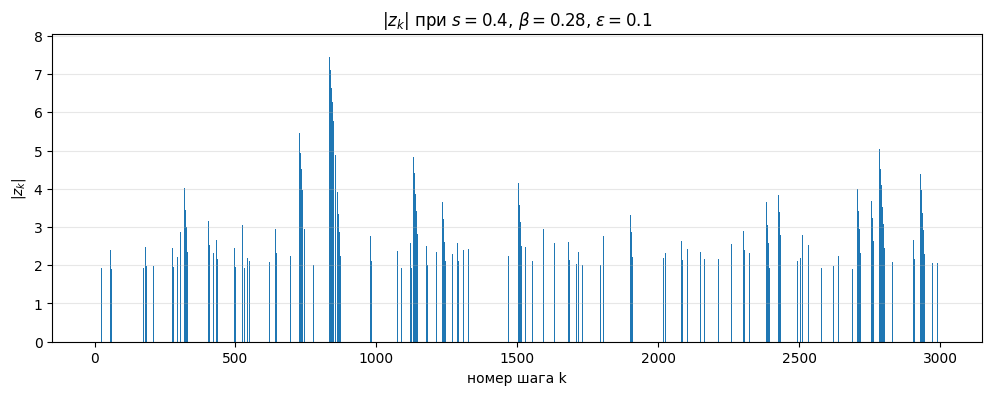

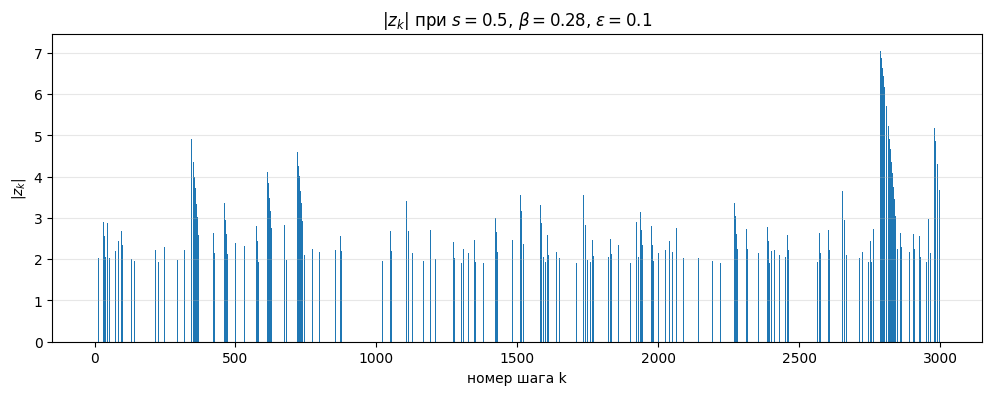

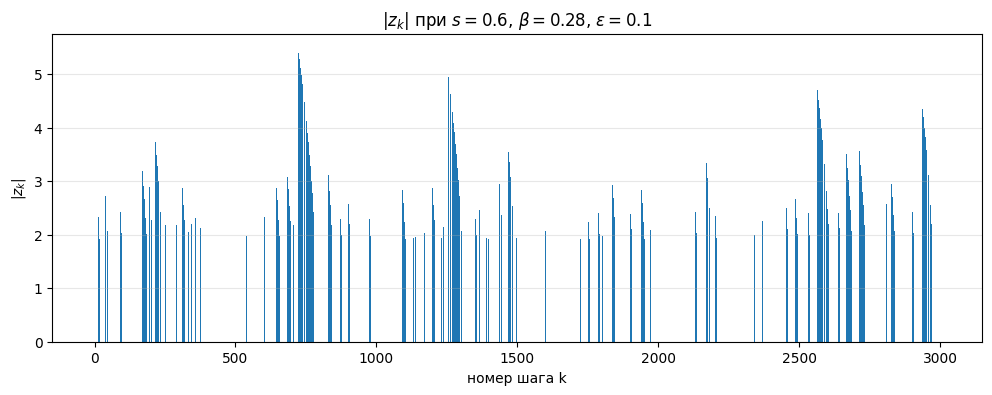

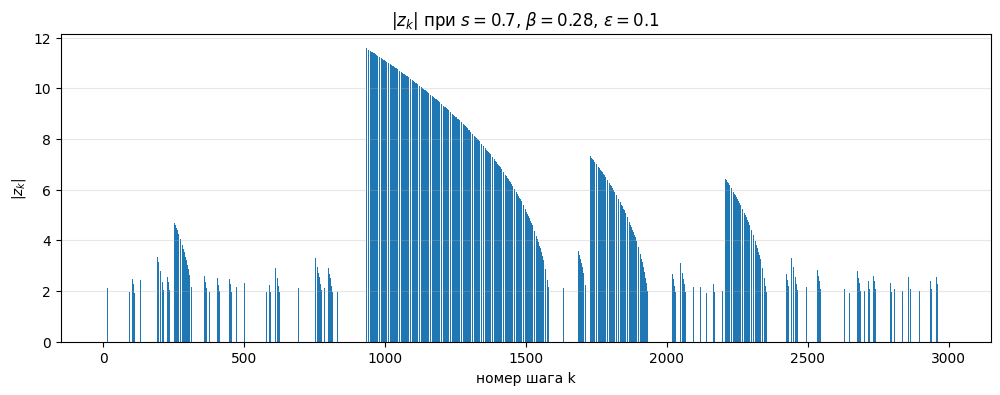

In [13]:
# Графики |z_k| для разных s при фиксированных beta и epsilon.

import matplotlib.pyplot as plt

for s_value in S_SWEEP_VALUES:
    df_s = s_sweep_df[s_sweep_df["s"] == s_value].sort_values("k").reset_index(drop=True)

    plt.figure(figsize=(12, 4))

    plt.bar(
        df_s["k"],
        df_s["abs_z"],
        width=0.8
    )

    plt.title(
        rf"$|z_k|$ при $s={s_value}$, "
        rf"$\beta={BETA_FIXED}$, $\varepsilon={EPS_FIXED}$"
    )
    plt.xlabel("номер шага k")
    plt.ylabel(r"$|z_k|$")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()


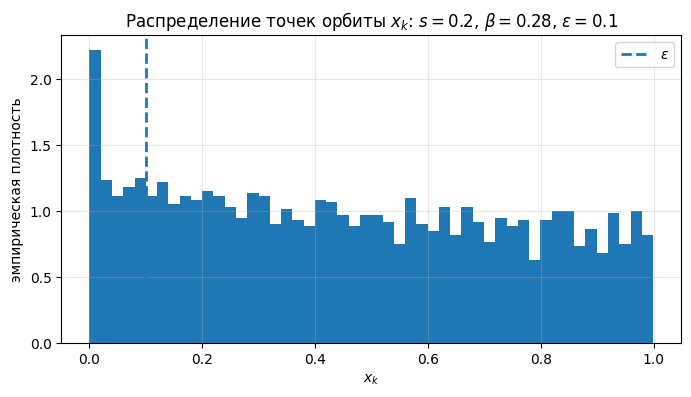

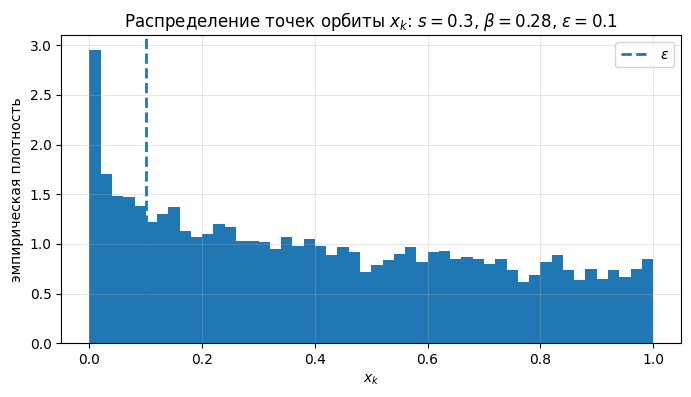

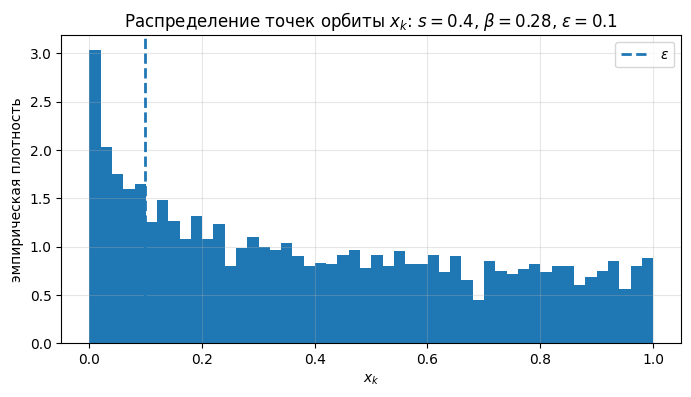

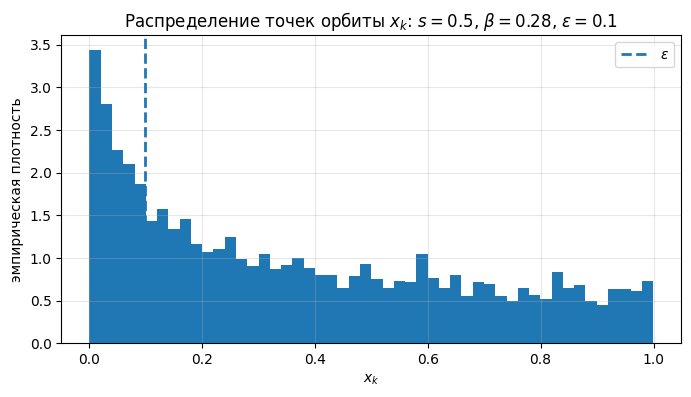

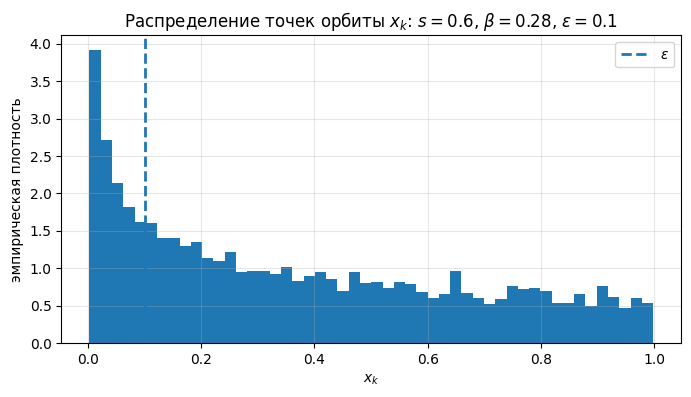

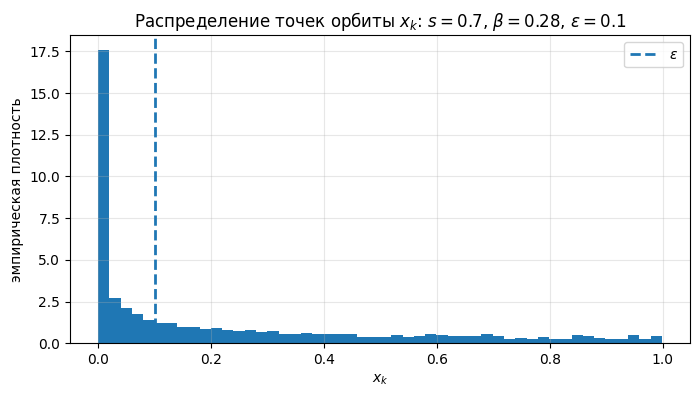

In [14]:
# Гистограммы значений орбиты x_k для разных s.
# Они показывают, насколько часто орбита находится около нуля.

import matplotlib.pyplot as plt

for s_value in S_SWEEP_VALUES:
    df_s = s_sweep_df[s_sweep_df["s"] == s_value].sort_values("k").reset_index(drop=True)

    plt.figure(figsize=(8, 4))

    plt.hist(
        df_s["x"],
        bins=50,
        density=True
    )

    plt.axvline(
        x=EPS_FIXED,
        linestyle="--",
        linewidth=2,
        label=r"$\varepsilon$"
    )

    plt.title(
        rf"Распределение точек орбиты $x_k$: "
        rf"$s={s_value}$, $\beta={BETA_FIXED}$, $\varepsilon={EPS_FIXED}$"
    )
    plt.xlabel(r"$x_k$")
    plt.ylabel("эмпирическая плотность")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


In [15]:
# Эксперимент по влиянию epsilon при фиксированных s и beta.
# epsilon меняет только порог включения шума, но не саму орбиту.

import numpy as np
import pandas as pd

S_FIXED_EPS_EXP = 0.5
BETA_FIXED_EPS_EXP = 0.28

EPS_SWEEP_VALUES = [0.03, 0.05, 0.07, 0.10, 0.20, 0.30, 0.50]

N_EPS_SWEEP = 3000
BURN_IN_EPS_SWEEP = 0

eps_sweep_dfs = []

for eps_value in EPS_SWEEP_VALUES:
    df = generate_thaler_noise(
        s=S_FIXED_EPS_EXP,
        beta=BETA_FIXED_EPS_EXP,
        epsilon=eps_value,
        x0=X0,
        n=N_EPS_SWEEP,
        burn_in=BURN_IN_EPS_SWEEP,
    )

    df.insert(
        0,
        "regime",
        f"s{S_FIXED_EPS_EXP:.2f}_beta{BETA_FIXED_EPS_EXP:.2f}_eps{eps_value:.2f}"
    )

    df["s"] = S_FIXED_EPS_EXP
    df["beta"] = BETA_FIXED_EPS_EXP
    df["epsilon"] = eps_value
    df["x0"] = X0

    eps_sweep_dfs.append(df)

eps_sweep_df = pd.concat(eps_sweep_dfs, ignore_index=True)

print("Таблица eps_sweep_df собрана.")
print("Размер:", eps_sweep_df.shape)
print(f"Фиксировано: s = {S_FIXED_EPS_EXP}, beta = {BETA_FIXED_EPS_EXP}")
print(f"Меняем epsilon: {EPS_SWEEP_VALUES}")
print(f"N = {N_EPS_SWEEP}, BURN_IN = {BURN_IN_EPS_SWEEP}")

display(eps_sweep_df.head(10))


Таблица eps_sweep_df собрана.
Размер: (21000, 10)
Фиксировано: s = 0.5, beta = 0.28
Меняем epsilon: [0.03, 0.05, 0.07, 0.1, 0.2, 0.3, 0.5]
N = 3000, BURN_IN = 0


,regime,k,x,z,abs_z,is_burst,s,beta,epsilon,x0
0,s0.50_beta0.28_eps0.03,0,0.323457,0.0,0.0,0,0.5,0.28,0.03,0.323457
1,s0.50_beta0.28_eps0.03,1,0.507417,0.0,0.0,0,0.5,0.28,0.03,0.323457
2,s0.50_beta0.28_eps0.03,2,0.868867,0.0,0.0,0,0.5,0.28,0.03,0.323457
3,s0.50_beta0.28_eps0.03,3,0.678764,0.0,0.0,0,0.5,0.28,0.03,0.323457
4,s0.50_beta0.28_eps0.03,4,0.237978,0.0,0.0,0,0.5,0.28,0.03,0.323457
5,s0.50_beta0.28_eps0.03,5,0.354071,0.0,0.0,0,0.5,0.28,0.03,0.323457
6,s0.50_beta0.28_eps0.03,6,0.564757,0.0,0.0,0,0.5,0.28,0.03,0.323457
7,s0.50_beta0.28_eps0.03,7,0.989173,0.0,0.0,0,0.5,0.28,0.03,0.323457
8,s0.50_beta0.28_eps0.03,8,0.972978,0.0,0.0,0,0.5,0.28,0.03,0.323457
9,s0.50_beta0.28_eps0.03,9,0.932719,0.0,0.0,0,0.5,0.28,0.03,0.323457


In [16]:
# Сводная таблица по влиянию epsilon.
# Увеличение epsilon обычно повышает частоту ненулевых значений шума.

def burst_run_lengths(is_burst_array):
    """Возвращает длины подряд идущих серий is_burst = 1."""
    runs = []
    current = 0

    for value in is_burst_array:
        if value == 1:
            current += 1
        else:
            if current > 0:
                runs.append(current)
                current = 0

    if current > 0:
        runs.append(current)

    return runs


rows = []

for eps_value, group in eps_sweep_df.groupby("epsilon"):
    group = group.sort_values("k").reset_index(drop=True)
    runs = burst_run_lengths(group["is_burst"].values)

    rows.append({
        "epsilon": eps_value,
        "s": S_FIXED_EPS_EXP,
        "beta": BETA_FIXED_EPS_EXP,
        "n": len(group),
        "n_bursts": int(group["is_burst"].sum()),
        "nonzero_share": group["is_burst"].mean(),
        "n_burst_runs": len(runs),
        "max_burst_run": max(runs) if len(runs) > 0 else 0,
        "mean_burst_run": np.mean(runs) if len(runs) > 0 else 0,
        "min_x": group["x"].min(),
        "max_abs_z": group["abs_z"].max(),
        "mean_abs_z": group["abs_z"].mean(),
        "q90_abs_z": group["abs_z"].quantile(0.90),
        "q95_abs_z": group["abs_z"].quantile(0.95),
        "q99_abs_z": group["abs_z"].quantile(0.99),
    })

eps_effect_summary = pd.DataFrame(rows).sort_values("epsilon").reset_index(drop=True)

display(eps_effect_summary)


,epsilon,s,beta,n,n_bursts,nonzero_share,n_burst_runs,max_burst_run,mean_burst_run,min_x,max_abs_z,mean_abs_z,q90_abs_z,q95_abs_z,q99_abs_z
0,0.03,0.5,0.28,3000,292,0.097333,40,58,7.300000,0.000907,7.109847,0.365706,0.000000,3.355043,5.218586
1,0.05,0.5,0.28,3000,441,0.147000,61,61,7.229508,0.000907,7.109847,0.488296,2.631993,3.355043,5.218586
2,0.07,0.5,0.28,3000,564,0.188000,85,63,6.635294,0.000907,7.109847,0.578692,2.631993,3.355043,5.218586
3,0.10,0.5,0.28,3000,746,0.248667,122,64,6.114754,0.000907,7.109847,0.699935,2.631993,3.355043,5.218586
4,0.20,0.5,0.28,3000,1163,0.387667,222,66,5.238739,0.000907,7.109847,0.938633,2.631993,3.355043,5.218586
5,0.30,0.5,0.28,3000,1480,0.493333,308,67,4.805195,0.000907,7.109847,1.095154,2.631993,3.355043,5.218586
6,0.50,0.5,0.28,3000,2004,0.668000,462,69,4.337662,0.000907,7.109847,1.322599,2.631993,3.355043,5.218586


In [17]:
# Компактная таблица по epsilon для вставки в текст работы.

eps_table_for_thesis = eps_effect_summary[
    [
        "epsilon",
        "n_bursts",
        "nonzero_share",
        "n_burst_runs",
        "max_burst_run",
        "mean_burst_run",
        "max_abs_z",
        "q99_abs_z",
    ]
].copy()

eps_table_for_thesis = eps_table_for_thesis.round({
    "epsilon": 3,
    "nonzero_share": 3,
    "mean_burst_run": 3,
    "max_abs_z": 3,
    "q99_abs_z": 3,
})

display(eps_table_for_thesis)


,epsilon,n_bursts,nonzero_share,n_burst_runs,max_burst_run,mean_burst_run,max_abs_z,q99_abs_z
0,0.03,292,0.097,40,58,7.300,7.11,5.219
1,0.05,441,0.147,61,61,7.230,7.11,5.219
2,0.07,564,0.188,85,63,6.635,7.11,5.219
3,0.10,746,0.249,122,64,6.115,7.11,5.219
4,0.20,1163,0.388,222,66,5.239,7.11,5.219
5,0.30,1480,0.493,308,67,4.805,7.11,5.219
6,0.50,2004,0.668,462,69,4.338,7.11,5.219


In [18]:
# Сохранение основных таблиц в CSV-файлы.
# В Google Colab файлы можно скачать из боковой панели Files.

noise_csv_path = "thaler_orbit_and_noise_values.csv"
summary_csv_path = "thaler_noise_summary.csv"

noise_df.to_csv(noise_csv_path, index=False)
summary_df.to_csv(summary_csv_path, index=False)

print("Saved full noise table:", noise_csv_path)
print("Saved summary table:", summary_csv_path)


Saved full noise table: thaler_orbit_and_noise_values.csv
Saved summary table: thaler_noise_summary.csv


## Использование в обучении

Полученная последовательность \(z_k\) далее может использоваться в модифицированном градиентном спуске с детерминированным возмущением Талера. Хвостовой показатель весовых коэффициентов оценивается отдельно после обучения модели.
